# ДЗ-2 по Теории и практике онлайн экспериментов


Данные лежат на диске: https://disk.yandex.ru/d/9EcCqk-1CUyiCA

### Задание 1 (4 балла)

Представим, что у нас есть сервис для продажи некоторых товаров (например, мыла). Мы выкатываем новые фичи и проводим тесты, а затем сохраняем логи каждого теста в следующем формате:

- `user_id` - уникальный id посетителя сайта
- `dt` - дата события
- `event` - название события
- `group` - группа, в которую попал пользователь (распределение может происходить на разных этапах воронки для разных тестов - например, при первом посещении или при первом добавлении в корзину)
- `visit_id` - уникальный id визита
- `cart_id` - уникальный id корзины
- `amount` - текущая сумма корзины
- `num_items` - текущее количество товаров в корзине


1. Обратимся к метрике **average revenue per paying user**. Вам даны две очень похожие группы (файл `aa_test_logs.pkl`). 

- Постройте распределение p-value для теста на равенство средних между группами.
- Найдите, на каком уровне искусственно добавленного эффекта средняя выручка в группах станет различима. Ошибку первого рода считайте заданной и равной 0.05, ошибку 2-го рода равной 0.2.

2. На данных `aa_test_logs.pkl` сравните мощность линеаризации, бутстрапа, бакетизации и дельта-метода для метрики **среднего чека**. Какой метод получился наиболее мощным? Как вы думаете, почему?

3. Мы сделали рекомендательную систему, которая после добавления товара в корзину предлагает добавить похожие или комплементарные. Логи проведенного теста сохранены в файле `ab_test_logs.pkl`. 

- Проверьте гипотезу о том, что это изменение значимо повлияло на ARPPU наших power users (95%-й процентиль).
- Проверьте гипотезу о том, что это изменение значимо повлияло на ARPPU всех юзеров.

### 1.1.1

In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.utils import resample

from scipy import stats as sts
from tqdm import tqdm

from time import time
from IPython.display import Markdown

import warnings
warnings.filterwarnings("ignore")

In [2]:
aa = pd.read_pickle('aa_test_logs.pkl')

aa_gr = aa.groupby(['user_id', 'cart_id']).agg({'event': ' '.join}).reset_index()

aa_gr = aa_gr[aa_gr.event.str.find('paid') != -1]
cart_id_list = aa_gr.cart_id

aa = aa.loc[(aa.cart_id.isin(cart_id_list)) & (aa.event != 'cart-paid')]

aa_gr = (
    aa.groupby(['user_id', 'cart_id', 'group']).amount.max().reset_index()
            ).groupby(['user_id', 'group'])\
             .agg({'amount': 'sum'})\
             .reset_index()\
             .merge(
                aa.groupby('user_id').cart_id.nunique().reset_index().rename(columns={'cart_id': 'cart_cnt'})
            )

control_aa = aa_gr[aa_gr.group == 'control']
test_aa = aa_gr[aa_gr.group == 'test']

In [3]:
aa_res = [
    sts.ttest_ind(control_aa.amount.sample(100, replace=True), 
                  test_aa.amount.sample(100, replace=True))[1] 
    for _ in range(1000)
]

ks-test U(0.003967732009254889, 0.9957094278442754), p-value = 0.51


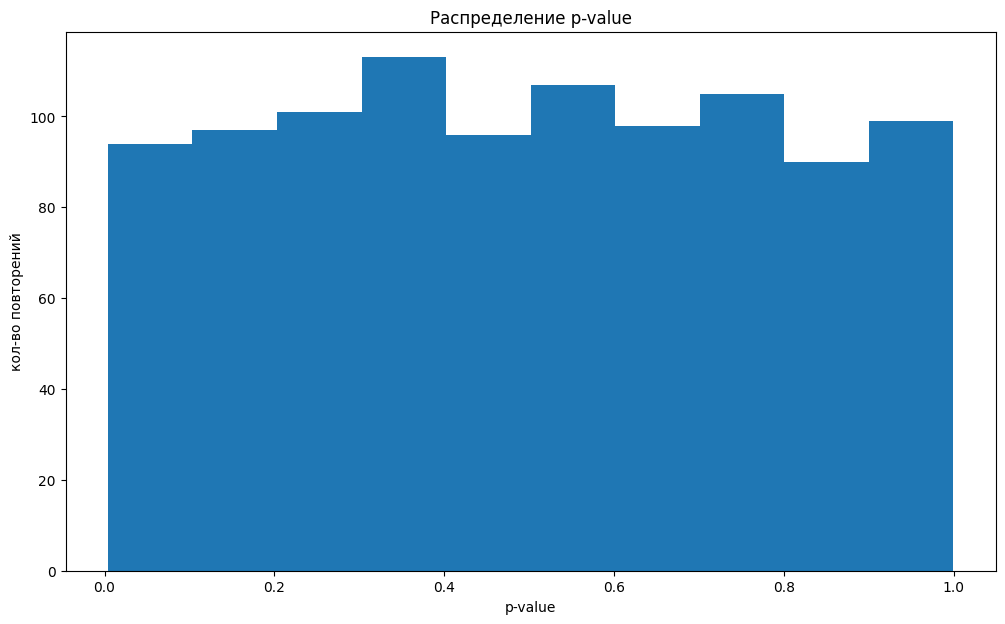

In [4]:
plt.figure(figsize=(12, 7)) 

plt.hist(aa_res)
plt.title('Распределение p-value')
plt.xlabel('p-value')
plt.ylabel('кол-во повторений');

print(f'ks-test U{sts.uniform.fit(aa_res)}, p-value = {sts.kstest(aa_res, sts.uniform.fit(aa_res))[1]:.2f}')

### 1.1.2

In [5]:
alpha=0.05
beta=0.2

control_len, test_len = control_aa.shape[0], test_aa.shape[0]

alpha_quant = sts.norm.ppf(1 - alpha/2)
beta_quant = sts.norm.ppf(1 - beta)

var_control = np.var(
    control_aa.amount, ddof=1
)
var_test = np.var(
    test_aa.amount, ddof=1
)

mde = np.sqrt(
    (alpha_quant + beta_quant)**2 * (var_control + var_test) / control_len
)

mde

np.float64(13.111665274100647)

### 1.2 

In [6]:
effect = np.random.normal(loc=7, scale=1, size=test_aa.shape[0])

In [7]:
def check_bootstrap(a: pd.DataFrame, b: pd.DataFrame, n_iter: int=1000):
    """
      Оценивает значимость отличий с помощью бутстрепа.

      Если отличия значимые, то возвращает 1, иначе 0.
    """
    xy_a, xy_b = a[['amount', 'cart_cnt']].values, b[['amount', 'cart_cnt']].values 

   
    # генерируем случайные индексы для выбора подмножеств данных
    len_a, len_b = len(a), len(b)
    indexes_a = np.random.choice(np.arange(len_a), size=(n_iter, len_a), replace=True)
    indexes_b = np.random.choice(np.arange(len_b), size=(n_iter, len_b), replace=True)

    bootstrap_stats = []

    for idx_a, idx_b in zip(indexes_a, indexes_b):
        bootstrap_xy_a, bootstrap_xy_b = xy_a[idx_a], xy_b[idx_b]

        # считаем разницу метрик отношения       
        bootstrap_stat = (
            bootstrap_xy_b[:, 0].sum() / bootstrap_xy_b[:, 1].sum()
          - bootstrap_xy_a[:, 0].sum() / bootstrap_xy_a[:, 1].sum()
        )

        bootstrap_stats.append(bootstrap_stat)

    # считаем реальную разность двух групп
    delta_mean = (
        np.sum(xy_b[:, 0]) / np.sum(xy_b[:, 1]) 
      - np.sum(xy_a[:, 0]) / np.sum(xy_a[:, 1])
      )
    std_delta_mean = np.std(bootstrap_stats)

    # считаем p-value
    pvalue_delta_mean = 2 * (1 - sts.norm.cdf(np.abs(delta_mean / std_delta_mean)))

    return pvalue_delta_mean

def check_delta_method(a, b):
    """Проверка гипотезы с помощью дельта-метода.

    Возвращает p-value.
    """
    dict_ = {}

    for data, group_name in [(a, "a"), (b, "b")]:
            
        n = len(data)

        array_x = data['amount'].values
        array_y = data['cart_cnt'].values

        mean_x, mean_y = np.mean(array_x), np.mean(array_y)
        var_x, var_y = np.var(array_x), np.var(array_y)
        cov_xy = np.cov(array_x, array_y)[0, 1]

        # точечная оценка метрики
        pe_metric = mean_x / mean_y

        # оценка дисперсии метрики
        var_metric = (
            var_x / mean_y**2
            - 2 * (mean_x / mean_y**3) * cov_xy
            + var_y * (mean_x**2 / mean_y**4)
        ) / n

        dict_[f"pe_metric_{group_name}"] = pe_metric
        dict_[f"var_metric_{group_name}"] = var_metric

    var = dict_["var_metric_a"] + dict_["var_metric_b"]
    delta = dict_["pe_metric_b"] - dict_["pe_metric_a"]
    t = delta / np.sqrt(var)
    pvalue = 2 * (1 - sts.norm.cdf(np.abs(t)))

    return pvalue

def check_linearization(a, b) :
    """Проверка гипотезы с помощью линеаризации."""
    
    a_x, a_y = a['amount'].values, a['cart_cnt'].values  
    b_x, b_y = b['amount'].values, b['cart_cnt'].values

    coef = np.sum(a_x) / np.sum(a_y)

    a_lin = a_x - coef * a_y
    b_lin = b_x - coef * b_y

    _, pvalue = sts.ttest_ind(a_lin, b_lin)

    delta = np.mean(b_lin) - np.mean(a_lin)

    return pvalue


  0%|          | 2/1000 [00:00<01:04, 15.39it/s]

100%|██████████| 1000/1000 [00:53<00:00, 18.75it/s]


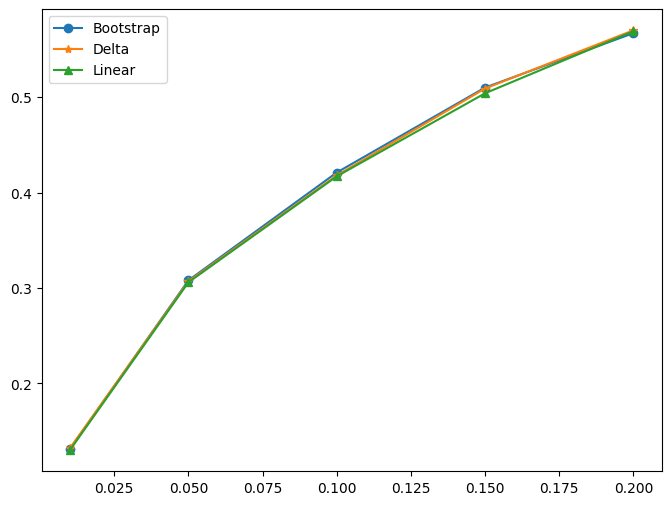

In [8]:
def make_ttests(test: pd.DataFrame, control: pd.DataFrame, effect: int=0, n_iter: int=1000):

    p_values = {method: [] for method in ['bootstrap', 'linearization', 'delta_method']}
    powers = {method: [] for method in ['bootstrap', 'linearization', 'delta_method']}

    for _ in tqdm(range(n_iter)):

        group_a = test.copy().sample(frac=1, replace=True)
        group_b = control.copy().sample(frac=1, replace=True)

        group_b.amount += effect

        p_value_boot = check_bootstrap(group_a, group_b)
        p_value_lin = check_linearization(group_a, group_b)
        p_value_delta = check_delta_method(group_a, group_b)

        p_values['bootstrap'].append(p_value_boot)
        p_values['linearization'].append(p_value_lin)
        p_values['delta_method'].append(p_value_delta)

    aplha_levels = [0.01, 0.05, 0.1, 0.15, 0.2]

    for alpha in aplha_levels:

        powers['bootstrap'].append(np.mean(np.array(p_values['bootstrap']) < alpha))
        powers['linearization'].append(np.mean(np.array(p_values['linearization']) < alpha))
        powers['delta_method'].append(np.mean(np.array(p_values['delta_method']) < alpha))

    plt.figure(figsize=(8, 6))

    plt.plot(aplha_levels, powers['bootstrap'], marker="o", label="Bootstrap")
    plt.plot(aplha_levels, powers['linearization'], marker="*", label="Delta")
    plt.plot(aplha_levels, powers['delta_method'], marker="^", label="Linear")

    plt.legend()

make_ttests(control_aa, test_aa, effect=7)

_как можно заметить дельта-метод и линеаризация оказались чуть лучше бутстрапа. предположительно, происходит это по причине того, что бутстрап не может гарантировать стабильный уровень мощности как альтернативные тесты_

### 1.2 Бакетизация

прикладываю наработки. до конца не был уверен в корректности

In [10]:
# bucket_size = 1000
# buckets_amount = 100

# pvalues = []

# for _ in tqdm(range(100)):
    
#     buckets_test = [
#         np.random.choice(aa[aa.group == 'test'].index, size=bucket_size, replace=False) for _ in range(buckets_amount)
#     ]
#     buckets_control = [
#         np.random.choice(aa[aa.group == 'control'].index, size=bucket_size, replace=False) for _ in range(buckets_amount)
#     ]

#     buckets_info_test = [(np.random.normal(7, 1, bucket_size) + aa.loc[bucket, 'amount']).sum() / aa.loc[bucket, 'cart_cnt'].sum() for bucket in buckets_test]
#     buckets_info_control = [aa.loc[bucket, 'amount'].sum() / aa.loc[bucket, 'cart_cnt'].sum() for bucket in buckets_control]

#     pvalues.append(
#         sts.ttest_ind(buckets_info_test, buckets_info_control, equal_var=False).pvalue
#     )

### 1.3

In [11]:
ab = pd.read_pickle('ab_test_logs.pkl')

ab_gr = ab.groupby(['user_id', 'cart_id']).agg({'event': ' '.join}).reset_index()

ab_gr = ab_gr[ab_gr.event.str.find('paid') != -1]
cart_id_list = ab_gr.cart_id

ab = ab.loc[(ab.cart_id.isin(cart_id_list)) & (ab.event != 'cart-paid')]

ab_gr = (
    ab.groupby(['user_id', 'cart_id', 'group']).amount.max().reset_index()
            ).groupby(['user_id', 'group'])\
             .agg({'amount': 'sum'})\
             .reset_index()

control_ab = ab_gr[ab_gr.group == 'control']
test_ab = ab_gr[ab_gr.group == 'test']

Статистика бутстрапа:
95.0% ДИ: (36.88; 134.53)
p-value: 0.0


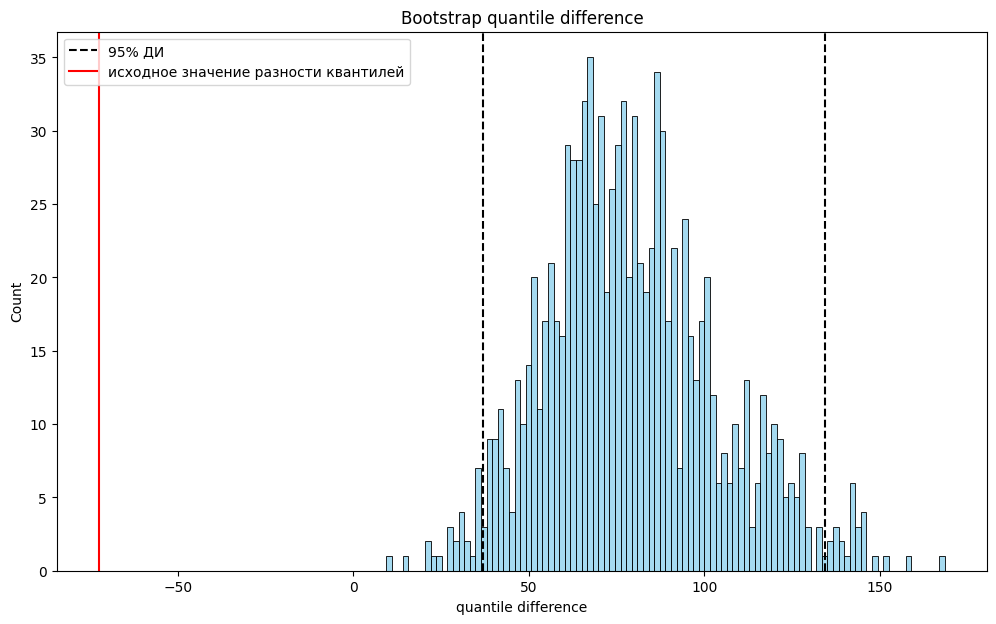

In [12]:
# строим бутстраповское распределение для разности квантилей:
# код был взят из группового проекта по эконометрике, другие участники группы: Томинец Александр, Черников Олег

x, y = control_ab.amount, test_ab.amount
q = 0.95

quantile_x, quantile_y = x.quantile(q), y.quantile(q)

diff = quantile_x - quantile_y

results = []

for i in range(1000):

    sample1 = resample(x)
    sample2 = resample(y)

    quantile1 = sample1.quantile(q)
    quantile2 = sample2.quantile(q)

    results.append(quantile2 - quantile1)

results = pd.Series(results)

right_q, left_q = results.quantile(0.975), results.quantile(0.025)
p_val = 2 * min(np.array([results > diff]).mean(), np.array([results < diff]).mean())

plt.figure(figsize=(12,7))

plt.title('Bootstrap quantile difference')
plt.xlabel('quantile difference')

sns.histplot(results, bins=100, color='skyblue')
plt.axvline(right_q, ls='--', color='black', label=f'{q*100:.0f}% ДИ')
plt.axvline(left_q, ls='--', color='black')
plt.axvline(diff, color='red', label='исходное значение разности квантилей')

plt.legend();

print('Статистика бутстрапа:')
print(f'{q*100}% ДИ: ({left_q:.2f}; {right_q:.2f})')
print(f'p-value: {p_val}')

Статистика бутстрапа:
95.0% ДИ: (-16.52; 3.19)
p-value: 0.998


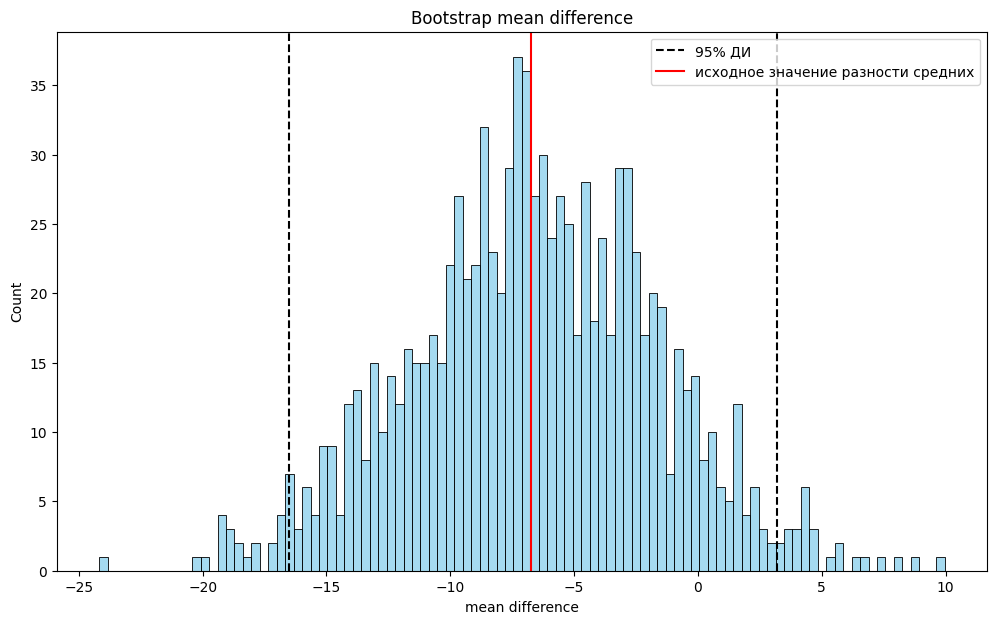

In [13]:
# строим бутстраповское распределение для разности квантилей:
# код был взят из группового проекта по эконометрике, другие участники группы: Томинец Александр, Черников Олег

x, y = control_ab.amount, test_ab.amount
q = 0.95

mean_x, mean_y = x.mean(), y.mean()
diff = mean_x - mean_y

results = []

for i in range(1000):
    sample1 = resample(x)
    sample2 = resample(y)

    mean1 = sample1.mean()
    mean2 = sample2.mean()

    results.append(mean1 - mean2)

results = pd.Series(results)

right_q, left_q = results.quantile(0.975), results.quantile(0.025)
p_val = 2 * min(np.array([results > diff]).mean(), np.array([results < diff]).mean())

plt.figure(figsize=(12,7))

plt.title('Bootstrap mean difference')
plt.xlabel('mean difference')

sns.histplot(results, bins=100, color='skyblue');
plt.axvline(right_q, ls='--', color='black', label=f'{q*100:.0f}% ДИ')
plt.axvline(left_q, ls='--', color='black')
plt.axvline(diff, color='red', label='исходное значение разности средних')

plt.legend()

print('Статистика бутстрапа:')
print(f'{q*100}% ДИ: ({left_q:.2f}; {right_q:.2f})')
print(f'p-value: {p_val}')

_изменения для power users получились значимыми, в то время как для общей массы пользователей ничего не поменялось. данный вывод получилось сделать визуально определив попадает 0 в границы ДИ_

### Задание 2 (1 балл)

В приложенном файле `sleep.csv` приведено время засыпания одного и того же человека в разные дни.

Нужно обработать эти данные и указать такое время суток (с точностью до минуты), после которого с вероятностью 0.9 этот человек уже спит.

Как можно оценить стандартное отклонение этой точечной оценки?

In [14]:
sleep = pd.read_csv('sleep.csv', header=0, names=['dt', 'indicator', 'offset'])

sleep

,dt,indicator,offset
0,2017-12-01 21:00:00,0,-60
1,2017-12-01 21:01:00,0,-59
2,2017-12-01 21:02:00,0,-58
3,2017-12-01 21:03:00,0,-57
4,2017-12-01 21:04:00,0,-56
...,...,...,...
11335,2018-02-01 23:55:00,1,115
11336,2018-02-01 23:56:00,1,116
11337,2018-02-01 23:57:00,1,117
11338,2018-02-01 23:58:00,1,118


In [15]:
sleep['dt'] = pd.to_datetime(sleep['dt'])
sleep['day'] = sleep['dt'].dt.floor('d')

sleep

,dt,indicator,offset,day
0,2017-12-01 21:00:00,0,-60,2017-12-01
1,2017-12-01 21:01:00,0,-59,2017-12-01
2,2017-12-01 21:02:00,0,-58,2017-12-01
3,2017-12-01 21:03:00,0,-57,2017-12-01
4,2017-12-01 21:04:00,0,-56,2017-12-01
...,...,...,...,...
11335,2018-02-01 23:55:00,1,115,2018-02-01
11336,2018-02-01 23:56:00,1,116,2018-02-01
11337,2018-02-01 23:57:00,1,117,2018-02-01
11338,2018-02-01 23:58:00,1,118,2018-02-01


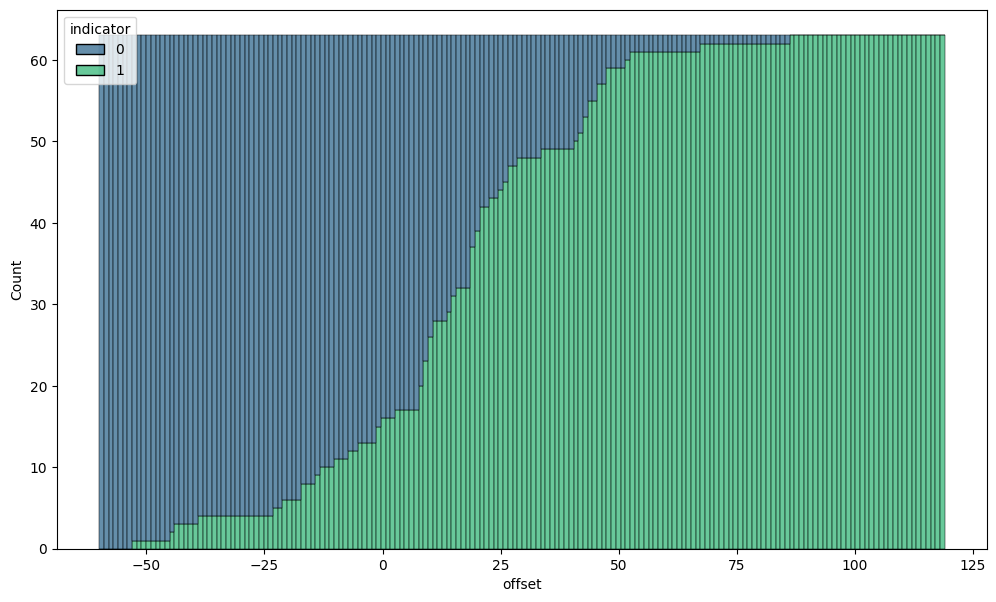

In [16]:
plt.figure(figsize=(12, 7))
sns.histplot(data=sleep, x='offset', 
             hue='indicator', multiple='stack', 
             bins=180, palette='viridis');

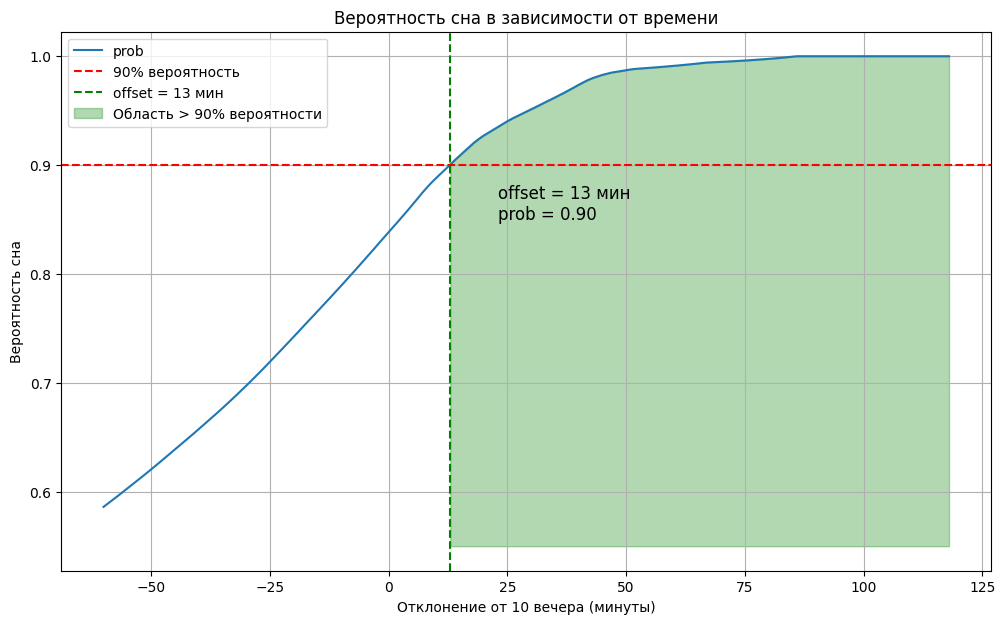

In [17]:
def sleep_prob(sleep=sleep):

    offset_list = sorted(sleep.offset.unique())
    offset_prob = {}

    for offset in offset_list:

        offset_prob[offset] = sleep.loc[sleep.offset > offset, 'indicator'].mean()

    return pd.DataFrame(data=offset_prob.items(), columns=['offset', 'prob'])

offset_opt = sleep_prob()

ax = offset_opt.set_index('offset').plot(figsize=(12, 7), 
                                         title='Вероятность сна в зависимости от времени')
plt.axhline(0.9, color='red', linestyle='--', label='90% вероятность')

intersection_point = offset_opt[offset_opt['prob'] >= 0.9].iloc[0]
x_intersect = intersection_point['offset']
y_intersect = intersection_point['prob']

ax.annotate(f'offset = {x_intersect:.0f} мин\nprob = {y_intersect:.2f}', 
            xy=(x_intersect, 0.9), 
            xytext=(x_intersect + 10, 0.85), 
            fontsize=12)

plt.axvline(x=x_intersect, color='green', 
            linestyle='--', label=f'offset = {x_intersect:.0f} мин')
plt.fill_between(
    offset_opt['offset'],  
    offset_opt['prob'],    
    0.55,                     
    where=(offset_opt['offset'] >= x_intersect),  
    color='green', 
    alpha=0.3, 
    label='Область > 90% вероятности'
)

plt.xlabel('Отклонение от 10 вечера (минуты)')
plt.ylabel('Вероятность сна')
plt.legend()
plt.grid()
plt.show()

### Задание 3. CUPED (1 балла)

Cгенерируем выборку из $1000$ сэмплов экспоненциального распределения - это будут значения нашей метрики для $1000$ пользователей

In [18]:
control_before = sts.expon(scale=1000).rvs(1000)

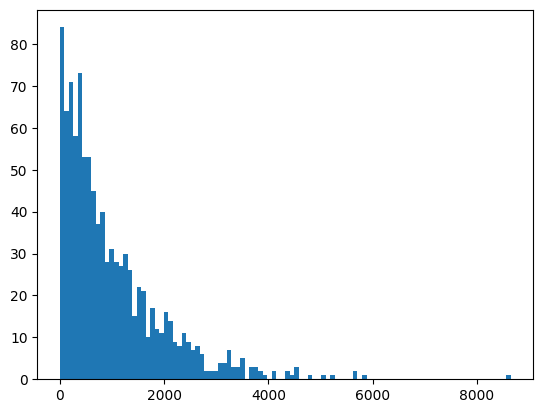

In [19]:
plt.hist(control_before, bins=100)
plt.show()

Предположим, что при наблюдении метрики в дальнейшем добавляется какой-то нормальный шум

In [20]:
control = control_before + sts.norm(loc=0, scale=100).rvs(1000)

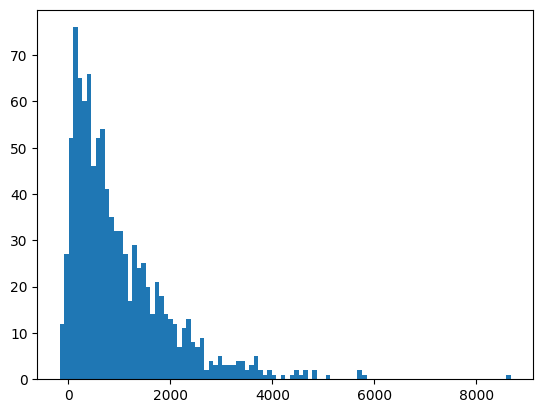

In [21]:
plt.hist(control, bins=100)
plt.show()

Теперь построим доверительный интервал для среднего значения нашей метрики и посмотрим, появилась ли стат значимая разница. Проведем такой эксперимент $10000$ раз

In [22]:
sts.norm(loc=control.mean(), scale=control.std() / np.sqrt(len(control))).ppf(
    [0.025, 0.975]
)

array([ 944.09501086, 1066.12182161])

In [23]:
bad_cnt = 0
N = 10000

for i in tqdm(range(N)):
    control_before = sts.expon(scale=1000).rvs(1000)
    control = control_before + sts.norm(loc=0, scale=100).rvs(1000)
    left_bound, right_bound = sts.norm(
        loc=control.mean(), scale=control.std() / np.sqrt(len(control))
    ).ppf([0.025, 0.975])

    if left_bound > 1000 or right_bound < 1000:
        bad_cnt += 1

print(f"Стат значимая разница есть в {round(bad_cnt / N, 4) * 100}% случаев;")

100%|██████████| 10000/10000 [00:08<00:00, 1210.69it/s]

Стат значимая разница есть в 5.19% случаев;


Как мы видим такой тест ошибается в около $5$% случаев, так как находит разницу в среднем. Ваша задача построить CUPED-метрику основываясь на данной метрике и провести аналогичный тест

In [24]:
bad_cnt = 0
N = 10000

for _ in tqdm(range(N)):
    control_before = sts.expon(scale=1000).rvs(1000)
    control = control_before + sts.norm(loc=0, scale=100).rvs(1000)

    theta = (
        np.cov(control, control_before)[1, 0] / 
        np.var(control_before)
    )
    control_cuped = (
        control - theta * (control_before - control_before.mean())
    ) # вынесли theta за скобку
    
    mean = control_cuped.mean()
    std = control_cuped.std() / np.sqrt(control_cuped.shape[0])

    left_bound, right_bound = sts.norm(loc=mean, scale=std).ppf([0.025, 0.975])

    if left_bound > 1000 or right_bound < 1000:
        bad_cnt += 1

print(f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев;")

100%|██████████| 10000/10000 [00:08<00:00, 1195.96it/s]

Стат значимая разница есть в  83.94% случаев;


_тк с помощью с помощью CUPED мы по сути сместили распределение, если можно так выразиться, из-за чего разница в средних действительно будет обнаружена. также, в отличие от следующих примеров, здесь требуется сравнить выходит ли матожидание за границы ДИ_

Результат должен получиться не очень хороший. Давайте теперь сделаем иначе: сгенерируем выборку из $10000$ значений, а затем выберем $2$ группы по $1000$ юзеров, которые будут нашими группами для теста. Опять добавим шум в обе группы аналогично тому, что показано в первом примере с теми же параметрами. Ваша задача вписать CUPED метрики используя знание обо всех $10000$ юзерах.

In [29]:
def make_cuped(obs, obs_before, theta = None, obs_before_full = None):
    obs_before_full = obs_before if obs_before_full is None else obs_before_full

    def make_theta(obs, obs_before, obs_before_full):
        return np.cov(obs_before, obs)[0, 1] / np.var(obs_before_full)

    theta = make_theta(obs, obs_before, obs_before_full) if theta is None else theta

    return obs - theta * (obs_before - obs_before_full.mean()) , theta

In [30]:
bad_cnt = 0
N = 10000

for _ in tqdm(range(N)):
    control_before_full = sts.expon(scale=1000).rvs(1000 * 10)
    samples_in_ab = 2000
    indexes_to_take_a = np.random.choice(
        range(samples_in_ab), samples_in_ab // 2, False
    )
    indexes_to_take_b = [x for x in range(samples_in_ab) if x not in indexes_to_take_a]

    control_before_a = control_before_full[indexes_to_take_a]
    control_before_b = control_before_full[indexes_to_take_b]

    control_after_a = control_before_a + sts.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )
    control_after_b = control_before_b + sts.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )

    control_cup_a, theta = make_cuped(
        obs=control_after_a, obs_before=control_before_a, theta=None, obs_before_full=control_before_full
    )
    
    control_cup_b, _ = make_cuped(
        obs=control_after_b, obs_before=control_before_b, theta=theta, obs_before_full=control_before_full
    )

    if sts.kstest(control_cup_a, control_cup_b).pvalue < 0.05:
        bad_cnt += 1

print(f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев;")

100%|██████████| 10000/10000 [00:43<00:00, 232.11it/s]

Стат значимая разница есть в  4.81% случаев;


Результат получился уже совсем другой. Опишите свои мысли по поводу того, из-за чего возникает такая разница:



_из-за того, что воспользовались бутстрапированными выборками, смещение за счет CUPED не было так заметно. сраниваем уже два распределения, одинаковое смещение которых не привело к статзначимому результату_

Далее проделаем такой же эксперимент при наличии реального смещения среднего значения и посмотрим на результаты с CUPED и без.

In [31]:
bad_cnt = 0
bad_cnt_cuped = 0
N = 10000

for i in tqdm(range(N)):

    control_before_full = sts.expon(scale=1000).rvs(1000 * 10)
    samples_in_ab = 2000
    indexes_to_take_a = np.random.choice(
        range(samples_in_ab), samples_in_ab // 2, False
    )

    indexes_to_take_b = [x for x in range(samples_in_ab) if x not in indexes_to_take_a]

    control_before_a = control_before_full[indexes_to_take_a]
    control_before_b = control_before_full[indexes_to_take_b]

    control_after_a = control_before_a + sts.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )
    control_after_b = control_before_b + sts.norm(loc=10, scale=100).rvs(
        samples_in_ab // 2
    )

    control_cup_a, theta = make_cuped(
        obs=control_after_a, obs_before=control_before_a, theta=None, obs_before_full=control_before_full
    )
    
    control_cup_b, _ = make_cuped(
        obs=control_after_b, obs_before=control_before_b, theta=theta, obs_before_full=control_before_full
    )

    if sts.kstest(control_after_a, control_after_b).pvalue < 0.05:
        bad_cnt += 1

    if sts.kstest(control_cup_a, control_cup_b).pvalue < 0.05:
        bad_cnt_cuped += 1

print(
    f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев; при использовании CUPED -- в {round(bad_cnt_cuped / N, 4) * 100}% случаев"
)

100%|██████████| 10000/10000 [00:46<00:00, 213.78it/s]

Стат значимая разница есть в  5.6899999999999995% случаев; при использовании CUPED -- в 41.64% случаев


_здесь уже мы действительно добавили весомое изменение и можем убедиться, что CUPED справился сильно лучше с его обнаружением_

### Задание 4. Методы снижения дисперсии (2 балла)

В этой части задания вам нужно применить методы снижения дисперсии с лекций, чтобы провести более точные тесты по данным из файла.

Данные представляют собой значение какой-то метрики для трех возрастных групп пользователей. Столбец group отвечает за группу, в которой находятся пользователи: 
- `None` - пользователь не участвует в АБ тесте, 
- `*_before_i` - соответствующая группа до начала теста, 
- `*_after_i` - группа после начала эксперимента

Чем больше i, тем позже было сделано наблюдение. 

Cчитайте, что юзеры всегда идут в одном порядке в группах. То есть `data[data.group == 'control_before_i']`
дает юзеров в той же последовательности, что `data[data.group == 'control_after_i']` для всех i.  Аналогичное верно для тритмента.


#### Что надо сделать:
1. Напишите тест Стьюдента самостоятельно - то есть вы должны сами вычислить тестовую статистику, а затем используя квантильную функцию определить p-value. Квантили можно брать из готовых библиотек.

2. Реализуйте пост-стратификацию и CUPED. 

3. Проведите тесты между `control_before_i` и `treatment_before_i` снчала без применения пост-стратификации и CUPED, а затем с ними. Без применения каких-либо методов такой тест покажет p-value около $0.05$ только при i == 5. Ваша задача применить методы уменьшения дисперсии, чтобы с помощью теста Стьюдента можно было обнаружить отличие на уровне значимости $0.05$

4. Опишите свои результаты.

In [32]:
data = pd.read_csv("data_ab.csv")

data

,age,metric,group
0,young,11309.036916,treatment_before
1,young,8496.554679,control_before
2,young,11891.862586,control_before
3,young,9229.445011,treatment_before
4,young,10410.961279,control_before
...,...,...,...
99995,old,7890.224384,treatment_after_5
99996,old,8165.046263,treatment_after_5
99997,old,10034.632118,treatment_after_5
99998,old,7564.445251,treatment_after_5


In [33]:
from typing import Tuple

def make_ttest(x: pd.Series, y: pd.Series) -> Tuple[float, float]: 

    mean_x, mean_y = x.mean(), y.mean()
    var_x, var_y = x.var(ddof=1), y.var(ddof=1)
    len_x, len_y = len(x), len(y)

    t_stat = (
        (mean_x - mean_y) / np.sqrt(var_x/len_x + var_y/len_y)
    )
    p_val = 2 * sts.t.cdf(-np.abs(t_stat), len_x + len_y - 2)

    return p_val, t_stat

def make_ttest_strat(x, y) -> Tuple[float, float]:

    mean_x, mean_y, var_x, var_y = 0,0,0,0

    for age in ['old', 'adult', 'young']: 
        strat_x, strat_y = x.loc[x['age'] == age, 'metric'], y.loc[y['age'] == age, 'metric']
        weight_strat_x, weight_strat_y = len(strat_x)/len(x), len(strat_y)/len(y)

        mean_x += weight_strat_x * strat_x.mean()
        mean_y += weight_strat_y * strat_y.mean()

        var_x += weight_strat_x * strat_x.var(ddof=1)
        var_y += weight_strat_y * strat_y.var(ddof=1)

    sigma = np.sqrt(
        var_x/len(x) + var_y/len(y)
    )

    t_stat = (
        (mean_x - mean_y) / sigma
    )
    p_val = 2 * sts.t.cdf(-np.abs(t_stat), len(x) + len(y) - 2)

    return p_val, t_stat

def make_ttest_cuped(treat_before, control_before, treat_after, control_after, before_full) -> float:

    before_full, after_full = np.hstack([treat_before, control_before]), np.hstack([treat_after, control_after])

    cov = np.cov(
        before_full, after_full
    )
    w = cov[0,1] / cov[0,0]

    control_cuped_a = treat_after - w * (treat_before - before_full.mean())
    control_cuped_b = control_after - w * (control_before - before_full.mean())

    return make_ttest(control_cuped_a, control_cuped_b)[0]


In [34]:
for i in range(1, 6):

    treatment = f"treatment_after_{i}"
    control = f"control_after_{i}"

    x = data.loc[data["group"] == treatment]
    y = data.loc[data["group"] == control]

    print(f"T-test, {i}st group - pvalue: {make_ttest(x['metric'], y['metric'])[0]}")
    print('----------')

T-test, 1st group - pvalue: 0.6922472240558739
----------
T-test, 2st group - pvalue: 0.4033494779637814
----------
T-test, 3st group - pvalue: 0.23366578647283137
----------
T-test, 4st group - pvalue: 0.12149348898963636
----------
T-test, 5st group - pvalue: 0.05381516856747038
----------


In [35]:
for i in range(1, 6):
    treatment = f"treatment_after_{i}"
    control = f"control_after_{i}"

    x = data.loc[data["group"] == treatment]
    y = data.loc[data["group"] == control]

    print(f"Stratification T-test, {i}st group - pvalue: {make_ttest_strat(x, y)[0]}")
    print('----------')

Stratification T-test, 1st group - pvalue: 0.3427017675836904
----------
Stratification T-test, 2st group - pvalue: 0.04686792385665732
----------
Stratification T-test, 3st group - pvalue: 0.004925830507202673
----------
Stratification T-test, 4st group - pvalue: 0.00028845932951346835
----------
Stratification T-test, 5st group - pvalue: 7.168855983535903e-06
----------


In [36]:
treatment_before = data.loc[data.group == 'treatment_before', 'metric'].reset_index(drop=True)
control_before = data.loc[data.group == 'control_before', 'metric'].reset_index(drop=True)

before_full = np.hstack([treatment_before, control_before])

for i in range(1, 6):
    a, b = (
        data.loc[data.group == f'treatment_after_{i}', 'metric'].reset_index(drop=True),
        data.loc[data.group == f'control_after_{i}', 'metric'].reset_index(drop=True)
    )
    
    p_val = make_ttest_cuped(treatment_before, control_before, a, b, before_full)
    print(f'CUPED T-test, {i}st group - pvalue: {p_val}')
    print('----------')

CUPED T-test, 1st group - pvalue: 1.738342188129714e-09
----------
CUPED T-test, 2st group - pvalue: 1.5751108076540748e-21
----------
CUPED T-test, 3st group - pvalue: 2.9995383453193916e-29
----------
CUPED T-test, 4st group - pvalue: 2.7867605678689325e-37
----------
CUPED T-test, 5st group - pvalue: 1.4339227782767115e-46
----------


_можем заметить, что удалось определить смещение только на CUPED и постстратификации, при том, что при использовании первого мы приходим к верному ответу уже на первой иттерации. данный пример показывает нам, что CUPED ускоряет наш тест, по крайней мере на данном примере, быстрее, что позволит бизнесу быстрее принять верное решение и сэкономить на этом_

_в случае с обычным t-тестом изменений между средними обнаружить не удалось даже на последней иттерации_

### Задание 5. Линеаризация + CUPED (2.5 балла)

1. В файле `duration_aa.csv` содержатся данные для АА-теста. Проверьте гипотезу о равенстве средних длительностей визита с помощью линеаризации, постройте распределение p-value.

2. Мы поменяли верстку нашего сайта и запустили АБ-тест, чтобы выяснить, увеличилась ли средняя продолжительность визита при новом дизайне. Результаты теста лежат в файле `duration_ab.csv`. С помощью линеаризованной метрики проверьте, есть ли разница в средней длительности визита между контрольной и тестовой группами.

3. Примените CUPED и снова проведите АБ-тест. Что произошло с p-value? Почему?

В каждом пункте необходимо визуализировать распределение p-value и сонаправленность линеаризованной разности метрик и разности ratio-метрик.

### 5.1

In [39]:
dur_aa = pd.read_csv('duration_aa.csv')

dur_aa

,Unnamed: 0,user_id,group,visit_id,visit_duration
0,0,JP1F82,first,ypn3ydiml32oelnslnjv,84.0
1,1,JP1F82,first,ypy93q2g8ypdtwbpv8b5,61.0
2,2,JP1F82,first,d8m6q0bmr40wgi6zuor3,81.0
3,3,JP1F82,first,5b72re4nr84fszqx7f6e,54.0
4,4,0Y2HSZ,first,z40pmuyaczi92gmlqz6t,97.0
...,...,...,...,...,...
11895,5975,VYZRIS,second,dwvgx6cp0ala3d3ejkcd,80.0
11896,5976,VYZRIS,second,b4fr6f9tm9tuwknfzc5o,76.0
11897,5977,VYZRIS,second,2yovstac7f9mlad3njpj,89.0
11898,5978,VYZRIS,second,b90q35tve1a5l99eypye,79.0


100%|██████████| 1000/1000 [00:00<00:00, 1122.87it/s]


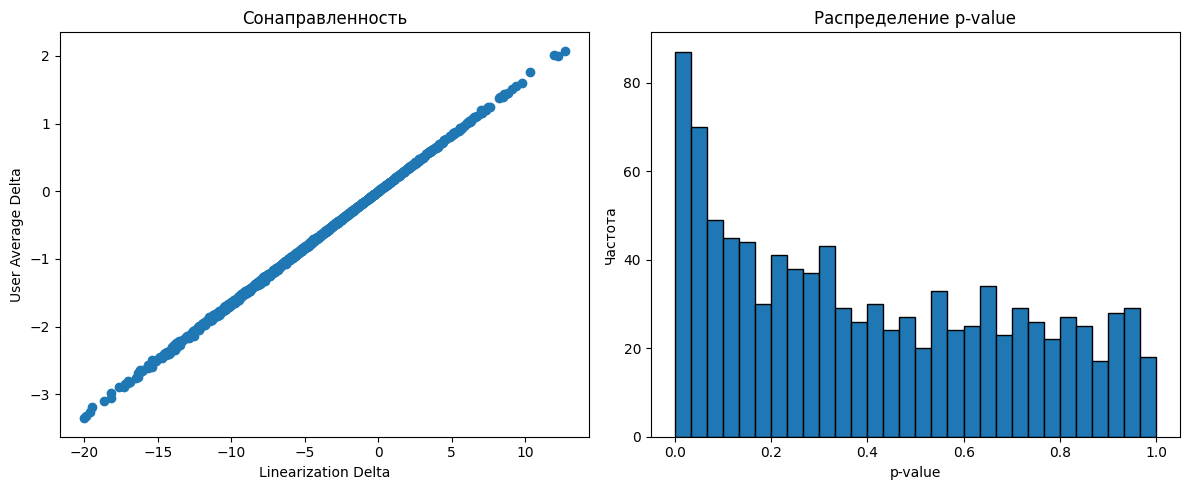

In [40]:
dur_aa_gr = (
    dur_aa.groupby(['user_id', 'group'])
          .agg({'visit_id': 'nunique', 'visit_duration': 'sum'})
          .rename(columns={'visit_id': 'visit_cnt'})
          .reset_index()
    )

first = dur_aa_gr[dur_aa_gr.group == 'first']
second = dur_aa_gr[dur_aa_gr.group == 'second']


def check_linearization(a: pd.DataFrame, b: pd.DataFrame, effect = effect) :
    """Проверка гипотезы с помощью линеаризации."""
    
    a_x = a['visit_duration'].values  
    a_y = a['visit_cnt'].values  
    b_x = b['visit_duration'].values + effect  
    b_y = b['visit_cnt'].values  

    coef = np.sum(a_x) / np.sum(a_y)

    a_lin = a_x - coef * a_y
    b_lin = b_x - coef * b_y

    _, pvalue = sts.ttest_ind(a_lin, b_lin, equal_var=False)

    delta = np.mean(b_lin) - np.mean(a_lin)

    return delta, pvalue

def exp(t: pd.Series, c: pd.Series, n_iter=10000):

    res = {key: {"delta": []} for key in ["linearization", "user_average"]}
    pvalues = []

    for _ in tqdm(range(n_iter)):
        a, b = resample(c), resample(t)

        delta, pvalue = check_linearization(a, b, effect=0)
        res["linearization"]["delta"].append(delta)

        delta = (
            np.sum(b.visit_duration) / np.sum(b.visit_cnt) 
          - np.sum(a.visit_duration) / np.sum(a.visit_cnt)
        )

        res["user_average"]["delta"].append(delta)
        pvalues.append(pvalue)

    return np.array(pvalues), res

pvalues, res = exp(first, second, 1000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  
plt.scatter(x=res["linearization"]["delta"], y=res["user_average"]["delta"])
plt.title('Сонаправленность')
plt.xlabel('Linearization Delta')
plt.ylabel('User Average Delta')

plt.subplot(1, 2, 2)  
plt.hist(pvalues, bins=30, edgecolor='black')
plt.title('Распределение p-value')
plt.xlabel('p-value')
plt.ylabel('Частота')

plt.tight_layout()

plt.show()

### 5.2

In [41]:
dur_ab = pd.read_csv('duration_ab.csv')

dur_ab

,Unnamed: 0,user_id,group,visit_id,visit_duration
0,0,AOXLT0,a,76v7fwlgmxa73cx08zvh,125.0
1,1,AOXLT0,a,dse16a8xow680xn4ly3o,115.0
2,2,AOXLT0,a,ei17obrkatjb0uglqglr,117.0
3,3,AOXLT0,a,cp9aczsn0zd8a7u9qoel,115.0
4,4,AOXLT0,a,t421ljy1eg7qpdx3dask,123.0
...,...,...,...,...,...
11930,5960,OUFK5V,b,r71fow7gm2hhonw94w8o,124.0
11931,5961,OUFK5V,b,qkl3b7ziw9p3vhuon62n,110.0
11932,5962,OUFK5V,b,c0iv57jkc2q60bas3eoz,130.0
11933,5963,OUFK5V,b,tsz0bo4a6n3lb243kenw,92.0


100%|██████████| 1000/1000 [00:00<00:00, 1116.77it/s]


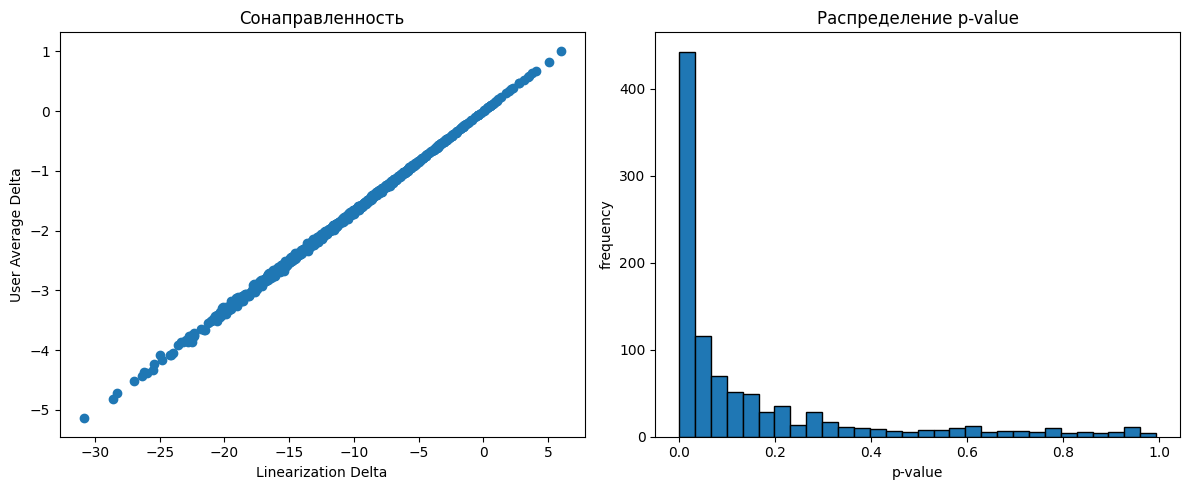

In [42]:
dur_ab_gr = (
    dur_ab.groupby(['user_id', 'group'])
          .agg({'visit_id': 'nunique', 'visit_duration': 'sum'})
          .rename(columns={'visit_id': 'visit_cnt'})
          .reset_index()
    )

a = dur_ab_gr[dur_ab_gr.group == 'a']
b = dur_ab_gr[dur_ab_gr.group == 'b']

pvalues, res = exp(a,b, 1000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  
plt.scatter(x=res["linearization"]["delta"], y=res["user_average"]["delta"])
plt.title('Сонаправленность')
plt.xlabel('Linearization Delta')
plt.ylabel('User Average Delta')

plt.subplot(1, 2, 2)  
plt.hist(pvalues, bins=30, edgecolor='black')
plt.title('Распределение p-value')
plt.xlabel('p-value')
plt.ylabel('frequency')

plt.tight_layout()

plt.show()

### 5.3

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:09<00:00, 1006.87it/s]


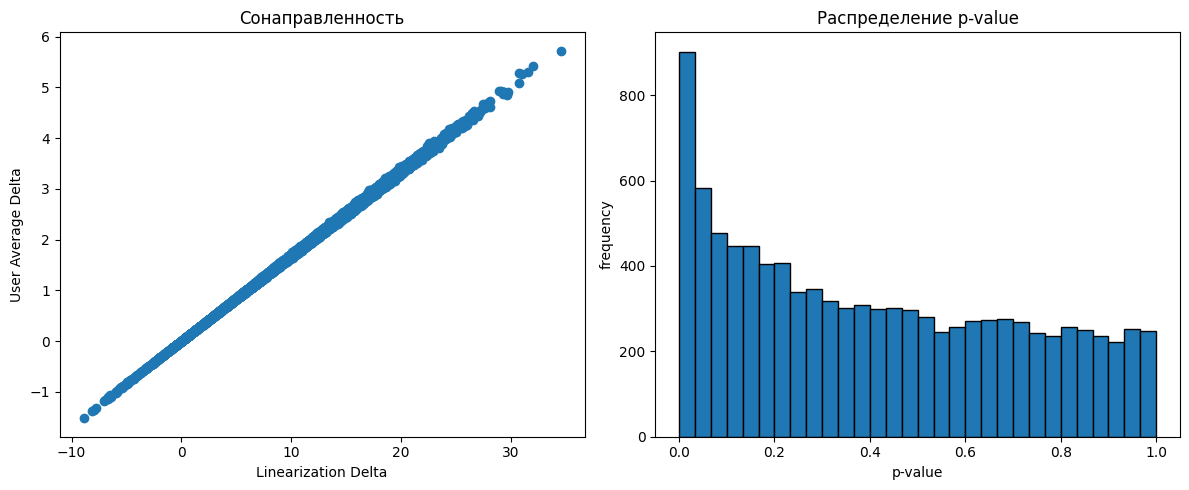

In [43]:
dur_ab_gr = (dur_ab.groupby(['user_id', 'group'])
                   .agg({'visit_id': 'nunique', 'visit_duration': 'sum'})
                   .rename(columns={'visit_id': 'visit_cnt'})
                   .reset_index())

hist = pd.read_csv('duration_hist.csv')
hist_gr = (hist.groupby('user_id')
               .agg({'visit_id': 'nunique', 'visit_duration': 'sum'})
               .reset_index())

dur_ab_gr = (
    dur_ab_gr
        .merge(hist_gr, on='user_id')
        .rename(columns={
            'visit_cnt': 'current_cnt',
            'visit_duration_x': 'current_duration',
            'visit_id': 'hist_cnt',
            'visit_duration_y': 'hist_duration'
        }))
a = dur_ab_gr[dur_ab_gr.group == 'a']
b = dur_ab_gr[dur_ab_gr.group == 'b']

def liniarized_cuped(a, b) :
    a_x, b_x = a['current_duration'].values, b['current_duration'].values
    a_y, b_y = a['current_cnt'].values, b['current_cnt'].values

    a_x_hist, b_x_hist = a['hist_duration'].values, b['hist_duration'].values
    a_y_hist, b_y_hist = a['hist_cnt'].values, b['hist_cnt'].values

    w = np.sum(a_x) / np.sum(a_y)
    
    a_lin, b_lin = (
        a_x - w * a_y,
        b_x - w * b_y
    )
    a_lin_hist, b_lin_hist = (
        a_x_hist - w * a_y_hist,
        b_x_hist - w * b_y_hist
    )

    delta = np.mean(b_lin) - np.mean(a_lin)

    x, y = (
        np.concatenate([a_lin_hist, a_lin]),
        np.concatenate([b_lin_hist, b_lin])
    )
    cov = np.cov(x,y)

    theta = cov[0,1] / cov[1,1]

    control_cuped = a_lin - w * (a_lin_hist - np.mean(y))
    test_cuped = b_lin - w * (b_lin_hist - np.mean(y))

    p_value = sts.ttest_ind(control_cuped,test_cuped).pvalue

    return delta, p_value


pvalues = []
res = {key: {"delta": []} for key in ["linearization", "user_average"]}

for _ in tqdm(range(10000)):
    sample_1, sample_2 = resample(a), resample(b)
    delta, pvalue = liniarized_cuped(sample_1, sample_2)

    res["linearization"]["delta"].append(delta)
    pvalues.append(pvalue)
    delta = np.sum(sample_2['current_duration'])/np.sum(sample_2['current_cnt']) \
          - np.sum(sample_1['current_duration'])/np.sum(sample_1['current_cnt']) 
    res["user_average"]["delta"].append(delta)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  
plt.scatter(x=res["linearization"]["delta"], y=res["user_average"]["delta"])
plt.title('Сонаправленность')
plt.xlabel('Linearization Delta')
plt.ylabel('User Average Delta')

plt.subplot(1, 2, 2)  
plt.hist(pvalues, bins=30, edgecolor='black')
plt.title('Распределение p-value')
plt.xlabel('p-value')
plt.ylabel('frequency')

plt.tight_layout()

plt.show()

_к сожалению или счастью, не удалось увидеть каких-либо изменений по отношению к двух предыдущим примерам из этого задания. все также соблюдается сонаправленнсть и экспоненциальное распределение p-value_